# DGraphFin Data Debug Notebook

Use this notebook to validate raw assets, replay preprocessing, and inspect the processed DGL graph. Each section mirrors helpers from `src/data/dgraph_fin.py` so you can pause, tweak logic, or capture snapshots mid-pipeline.


# Notebook Setup

## Colab Setup
Run the cells in this section if running this notebook in colab.
This will ensure the proper versions and avoid conflicts of key graph libraries.

In [ ]:
# Pull in the Repo - DGL Variant
!git clone --branch 01_DGL_variant --single-branch https://github.com/jamjahal/pruned-graphsage-fraud.git

In [ ]:
# Navigate into the repo
%cd pruned-graphsage-fraud

In [ ]:
# Resolve dgl / pytorch dependency issues.  May be prompted to restart notebook after running this cell the first time.
!pip uninstall dgl torch torchdata torchvision torchaudio -y
!pip install torch==2.4.0 --index-url https://download.pytorch.org/whl/test/cu124
!pip install torchdata==0.8.0
!pip install dgl==2.4.0 -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

In [ ]:
# Check imports
import torch
import torchdata
print(f'torchdata version: {torchdata.__version__}')
import dgl

print(f"PyTorch CUDA version: {torch.version.cuda}")
print(f"DGL is successfully imported!")

## Imports

In [5]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Dict, Optional

import dgl
import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

os.chdir(project_root)
print(f"Project root set to: {project_root}")

from src.data.dgraph_fin import load_dgraphfin_dataset


ModuleNotFoundError: No module named 'dgl'

## Set Parameters

In [6]:
DATA_DIR = project_root / "data"
DGRAPHFIN_ROOT = DATA_DIR / "DGraphFin2"
RAW_DIR = DGRAPHFIN_ROOT / "raw"
PROCESSED_DIR = DGRAPHFIN_ROOT / "processed"
OG_NPZ = DATA_DIR / "DGraphFin" / "dgraphfin.npz"
EDGE_TS_V2 = RAW_DIR / "dgraphfinv2_edge_timestamp.npy"
NODE_TS_V2 = RAW_DIR / "dgraphfinv2_node_timestamp.npy"

print("Configured paths:")
for name, path in (
    ("OG_NPZ", OG_NPZ),
    ("EDGE_TS_V2", EDGE_TS_V2),
    ("NODE_TS_V2", NODE_TS_V2),
    ("PROCESSED_DIR", PROCESSED_DIR),
):
    print(f"  {name:<14} -> {path}")


Configured paths:
  OG_NPZ         -> /Users/jameshall/UCLA/260D/project/data/DGraphFin/dgraphfin.npz
  EDGE_TS_V2     -> /Users/jameshall/UCLA/260D/project/data/DGraphFin2/raw/dgraphfinv2_edge_timestamp.npy
  NODE_TS_V2     -> /Users/jameshall/UCLA/260D/project/data/DGraphFin2/raw/dgraphfinv2_node_timestamp.npy
  PROCESSED_DIR  -> /Users/jameshall/UCLA/260D/project/data/DGraphFin2/processed


## Check filespaths

In [7]:
def describe_path(path: Path) -> Dict[str, object]:
    info: Dict[str, object] = {"path": str(path), "exists": path.exists()}
    if path.exists():
        stat = path.stat()
        info["size_mb"] = round(stat.st_size / (1024 ** 2), 2)
        info["modified"] = stat.st_mtime
    return info


def show_asset_report():
    assets = {
        "og_npz": describe_path(OG_NPZ),
        "edge_ts_v2": describe_path(EDGE_TS_V2),
        "node_ts_v2": describe_path(NODE_TS_V2),
        "processed_dir": describe_path(PROCESSED_DIR),
    }
    print(json.dumps(assets, indent=2))


show_asset_report()


{
  "og_npz": {
    "path": "/Users/jameshall/UCLA/260D/project/data/DGraphFin/dgraphfin.npz",
    "exists": true,
    "size_mb": 648.8,
    "modified": 1650359551.0
  },
  "edge_ts_v2": {
    "path": "/Users/jameshall/UCLA/260D/project/data/DGraphFin2/raw/dgraphfinv2_edge_timestamp.npy",
    "exists": true,
    "size_mb": 16.41,
    "modified": 1698287037.0
  },
  "node_ts_v2": {
    "path": "/Users/jameshall/UCLA/260D/project/data/DGraphFin2/raw/dgraphfinv2_node_timestamp.npy",
    "exists": true,
    "size_mb": 14.12,
    "modified": 1698287038.0
  },
  "processed_dir": {
    "path": "/Users/jameshall/UCLA/260D/project/data/DGraphFin2/processed",
    "exists": true,
    "size_mb": 0.0,
    "modified": 1764438764.8227441
  }
}


# Read and Process Data

In [4]:
def manual_preprocess(seed: int = 42) -> dgl.DGLGraph:
    """Mimic the loader logic to build a DGLGraph directly from raw assets."""
    if not OG_NPZ.exists():
        raise FileNotFoundError(f"Missing {OG_NPZ}. See data/DGraphFin/Readme.md for download steps.")

    with np.load(OG_NPZ) as f:
        x = torch.from_numpy(f["x"]).float()
        y_multi = f["y"]
        y = torch.from_numpy((y_multi == 1).astype(np.int64)).long()
        edge_index = f["edge_index"]
        src = torch.from_numpy(edge_index[:, 0]).long()
        dst = torch.from_numpy(edge_index[:, 1]).long()

        num_nodes = x.size(0)
        graph = dgl.graph((src, dst), num_nodes=num_nodes)
        graph.ndata["feat"] = x
        graph.ndata["label"] = y

        if "edge_timestamp" in f:
            edge_ts = torch.from_numpy(f["edge_timestamp"]).long()
            if edge_ts.shape[0] == graph.num_edges():
                graph.edata["timestamp"] = edge_ts

        def _build_masks(train_idx, val_idx, test_idx):
            train_mask = torch.zeros(num_nodes, dtype=torch.bool)
            val_mask = torch.zeros(num_nodes, dtype=torch.bool)
            test_mask = torch.zeros(num_nodes, dtype=torch.bool)
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            test_mask[test_idx] = True
            return train_mask, val_mask, test_mask

        if all(k in f for k in ("train_mask", "valid_mask", "test_mask")):
            train_nodes = torch.from_numpy(f["train_mask"]).long()
            val_nodes = torch.from_numpy(f["valid_mask"]).long()
            test_nodes = torch.from_numpy(f["test_mask"]).long()
        else:
            rng = np.random.default_rng(seed)
            perm = rng.permutation(num_nodes)
            n_train = int(0.7 * num_nodes)
            n_val = int(0.1 * num_nodes)
            train_nodes = torch.from_numpy(perm[:n_train]).long()
            val_nodes = torch.from_numpy(perm[n_train : n_train + n_val]).long()
            test_nodes = torch.from_numpy(perm[n_train + n_val :]).long()

        train_mask, val_mask, test_mask = _build_masks(train_nodes, val_nodes, test_nodes)
        graph.ndata["train_mask"] = train_mask
        graph.ndata["val_mask"] = val_mask
        graph.ndata["test_mask"] = test_mask

    if EDGE_TS_V2.exists():
        edge_ts_v2 = np.load(EDGE_TS_V2)
        if edge_ts_v2.shape[0] == graph.num_edges():
            graph.edata["timestamp"] = torch.from_numpy(edge_ts_v2).long()

    if NODE_TS_V2.exists():
        node_ts_v2 = np.load(NODE_TS_V2)
        if node_ts_v2.shape[0] == graph.num_nodes():
            graph.ndata["timestamp"] = torch.from_numpy(node_ts_v2).long()

    return graph


manual_graph = manual_preprocess()
manual_graph


NameError: name 'dgl' is not defined

In [ ]:
def summarize_graph(graph: dgl.DGLGraph) -> Dict[str, object]:
    summary: Dict[str, object] = {
        "num_nodes": graph.num_nodes(),
        "num_edges": graph.num_edges(),
        "num_features": graph.ndata["feat"].shape[1],
    }
    label_counts = torch.bincount(graph.ndata["label"].view(-1), minlength=2).tolist()
    summary["label_counts"] = {"neg": label_counts[0], "pos": label_counts[1]}
    summary["pos_ratio"] = round(label_counts[1] / max(sum(label_counts), 1), 4)

    for name in ("train_mask", "val_mask", "test_mask"):
        if name in graph.ndata:
            summary[name] = int(graph.ndata[name].sum().item())

    if "timestamp" in graph.edata:
        ts = graph.edata["timestamp"].float()
        summary["edge_timestamp_range"] = (float(ts.min().item()), float(ts.max().item()))
    if "timestamp" in graph.ndata:
        ts = graph.ndata["timestamp"].float()
        summary["node_timestamp_range"] = (float(ts.min().item()), float(ts.max().item()))
    return summary


print(json.dumps(summarize_graph(manual_graph), indent=2))


{
  "num_nodes": 3700550,
  "num_edges": 4300999,
  "num_features": 17,
  "label_counts": {
    "neg": 3685041,
    "pos": 15509
  },
  "pos_ratio": 0.0042,
  "train_mask": 857899,
  "val_mask": 183862,
  "test_mask": 183840,
  "edge_timestamp_range": [
    0.0,
    790.0
  ],
  "node_timestamp_range": [
    -2147483648.0,
    793.0
  ]
}


In [ ]:
dataset = load_dgraphfin_dataset(root=str(DGRAPHFIN_ROOT))
graph = dataset[0]
print(graph)
print(json.dumps(summarize_graph(graph), indent=2))


Data(x=[3700550, 17], edge_index=[2, 4300999], y=[3700550], edge_timestamp=[4300999], train_mask=[3700550], val_mask=[3700550], test_mask=[3700550], node_timestamp=[3700550])
{
  "num_nodes": 3700550,
  "num_edges": 4300999,
  "num_features": 17,
  "label_counts": {
    "neg": 3685041,
    "pos": 15509
  },
  "pos_ratio": 0.0042,
  "train_mask": 857899,
  "val_mask": 183862,
  "test_mask": 183840,
  "edge_timestamp_range": [
    0.0,
    790.0
  ],
  "node_timestamp_range": [
    -2147483648.0,
    793.0
  ]
}


In [ ]:
def preview_nodes(graph: dgl.DGLGraph, node_ids: Optional[np.ndarray] = None, k: int = 5):
    node_ids = node_ids if node_ids is not None else np.arange(k)
    rows = []
    feats = graph.ndata["feat"]
    labels = graph.ndata["label"]
    train_mask = graph.ndata.get("train_mask")
    val_mask = graph.ndata.get("val_mask")
    test_mask = graph.ndata.get("test_mask")
    node_ts = graph.ndata.get("timestamp")

    for nid in node_ids[:k]:
        feat_vec = feats[nid]
        row = {
            "node_id": int(nid),
            "label": int(labels[nid]),
            "train": bool(train_mask[nid]) if train_mask is not None else None,
            "val": bool(val_mask[nid]) if val_mask is not None else None,
            "test": bool(test_mask[nid]) if test_mask is not None else None,
            "feat_mean": float(feat_vec.mean().item()),
            "feat_std": float(feat_vec.std().item()),
        }
        if node_ts is not None:
            row["node_ts"] = int(node_ts[nid])
        rows.append(row)
    return rows


preview_nodes(graph)


[{'node_id': 0,
  'label': 0,
  'train': False,
  'val': False,
  'test': False,
  'feat_mean': -0.529411792755127,
  'feat_std': 1.462773323059082,
  'node_ts': -2147483648},
 {'node_id': 1,
  'label': 0,
  'train': False,
  'val': False,
  'test': False,
  'feat_mean': -0.9411764740943909,
  'feat_std': 0.24253562092781067,
  'node_ts': -2147483648},
 {'node_id': 2,
  'label': 0,
  'train': False,
  'val': False,
  'test': False,
  'feat_mean': -0.529411792755127,
  'feat_std': 1.462773323059082,
  'node_ts': -2147483648},
 {'node_id': 3,
  'label': 0,
  'train': False,
  'val': False,
  'test': False,
  'feat_mean': -0.47058823704719543,
  'feat_std': 1.5048940181732178,
  'node_ts': -2147483648},
 {'node_id': 4,
  'label': 0,
  'train': False,
  'val': False,
  'test': False,
  'feat_mean': -0.3529411852359772,
  'feat_std': 1.9666334390640259,
  'node_ts': -2147483648}]

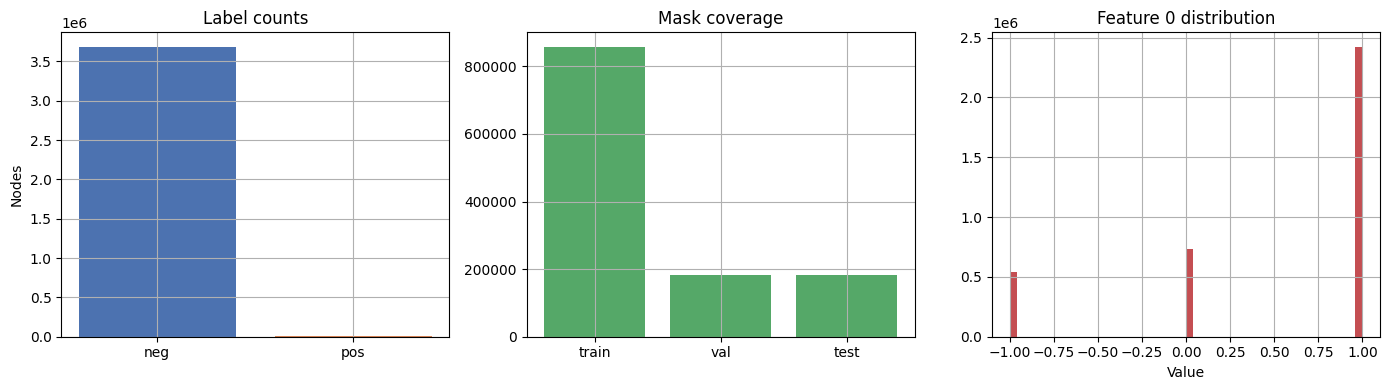

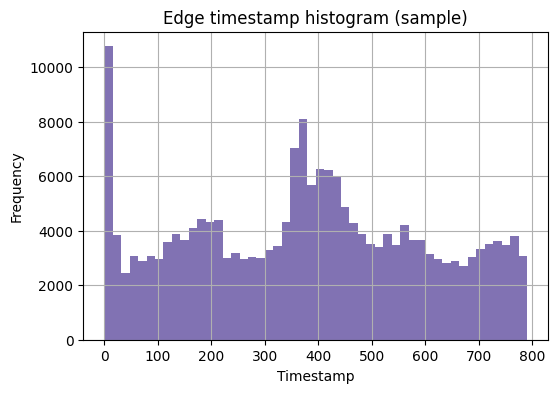

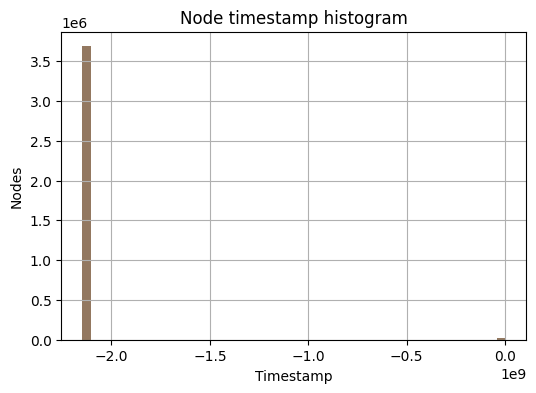

In [ ]:
label_counts = torch.bincount(graph.ndata["label"].cpu(), minlength=2).numpy()
mask_sizes = {
    name: int(graph.ndata[name].sum())
    for name in ("train_mask", "val_mask", "test_mask")
    if name in graph.ndata
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(["neg", "pos"], label_counts, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Label counts")
axes[0].set_ylabel("Nodes")

axes[1].bar(mask_sizes.keys(), mask_sizes.values(), color="#55A868")
axes[1].set_title("Mask coverage")

axes[2].hist(graph.ndata["feat"][:, 0].cpu().numpy(), bins=50, color="#C44E52")
axes[2].set_title("Feature 0 distribution")
axes[2].set_xlabel("Value")
plt.tight_layout()
plt.show()

edge_ts = graph.edata.get("timestamp")
if edge_ts is not None:
    edge_ts_np = edge_ts.cpu().numpy()
    sample = edge_ts_np if edge_ts_np.size <= 200_000 else np.random.choice(edge_ts_np, 200_000, replace=False)
    plt.hist(sample, bins=50, color="#8172B3")
    plt.title("Edge timestamp histogram (sample)")
    plt.xlabel("Timestamp")
    plt.ylabel("Frequency")
    plt.show()

node_ts = graph.ndata.get("timestamp")
if node_ts is not None:
    node_ts_np = node_ts.cpu().numpy()
    plt.hist(node_ts_np, bins=50, color="#937860")
    plt.title("Node timestamp histogram")
    plt.xlabel("Timestamp")
    plt.ylabel("Nodes")
    plt.show()


In [15]:
print("DGL materializes graphs on demand; there is no serialized processed file to inspect.")


None


In [16]:
def compare_manual_vs_processed(manual: dgl.DGLGraph, loaded: dgl.DGLGraph) -> Dict[str, object]:
    diff = {
        "num_nodes_equal": manual.num_nodes() == loaded.num_nodes(),
        "num_edges_equal": manual.num_edges() == loaded.num_edges(),
        "feat_close": torch.allclose(manual.ndata["feat"], loaded.ndata["feat"]),
        "labels_equal": torch.equal(manual.ndata["label"], loaded.ndata["label"]),
    }
    manual_edges = torch.stack(manual.edges(order="eid"))
    loaded_edges = torch.stack(loaded.edges(order="eid"))
    diff["edges_equal"] = torch.equal(manual_edges, loaded_edges)
    if "timestamp" in manual.edata and "timestamp" in loaded.edata:
        diff["edge_ts_equal"] = torch.equal(manual.edata["timestamp"], loaded.edata["timestamp"])
    if "timestamp" in manual.ndata and "timestamp" in loaded.ndata:
        diff["node_ts_equal"] = torch.equal(manual.ndata["timestamp"], loaded.ndata["timestamp"])
    for name in ("train_mask", "val_mask", "test_mask"):
        if name in manual.ndata and name in loaded.ndata:
            diff[f"{name}_equal"] = torch.equal(manual.ndata[name], loaded.ndata[name])
    return diff


print(json.dumps(compare_manual_vs_processed(manual_graph, graph), indent=2))


Loaded serialized data from /Users/jameshall/UCLA/260D/project/data/DGraphFin2/processed/dgraphfin.pt
No slices (single graph dataset)


In [17]:
def inspect_neighbors(graph: dgl.DGLGraph, node_id: int, limit: int = 10):
    src, dst = graph.edges(order="eid")
    mask = (src == node_id) | (dst == node_id)
    selected_src = src[mask]
    selected_dst = dst[mask]
    timestamps = graph.edata.get("timestamp")
    edge_ts = timestamps[mask] if timestamps is not None else None

    print(f"Node {node_id} participates in {selected_src.numel()} edges.")
    for idx in range(min(limit, selected_src.numel())):
        src_id = int(selected_src[idx])
        dst_id = int(selected_dst[idx])
        edge_info = {"idx": idx, "src": src_id, "dst": dst_id, "src_label": int(graph.ndata["label"][src_id]), "dst_label": int(graph.ndata["label"][dst_id])}
        if edge_ts is not None:
            edge_info["timestamp"] = int(edge_ts[idx])
        print(edge_info)


inspect_neighbors(graph, node_id=0, limit=5)


{
  "x_close": true,
  "edge_index_equal": true,
  "y_equal": true,
  "edge_ts_equal": true,
  "node_ts_equal": true,
  "train_mask_equal": true,
  "val_mask_equal": true,
  "test_mask_equal": true
}


In [18]:
mask_tensors = [graph.ndata[name].float() for name in ("train_mask", "val_mask", "test_mask") if name in graph.ndata]
mask_matrix = torch.stack(mask_tensors).numpy() if mask_tensors else np.zeros((0, graph.num_nodes()))

plt.figure(figsize=(10, 2))
plt.imshow(mask_matrix, aspect="auto", cmap="viridis")
plt.yticks(range(len(mask_tensors)), [name.split('_')[0] for name in ("train_mask", "val_mask", "test_mask") if name in graph.ndata])
plt.title("Mask coverage heatmap")
plt.xlabel("Node index slice")
plt.colorbar(label="Mask value")
plt.show()


Node 0 participates in 1 edges.
{'idx': 0, 'src': 146154, 'dst': 0, 'src_label': 0, 'dst_label': 0, 'timestamp': 78}


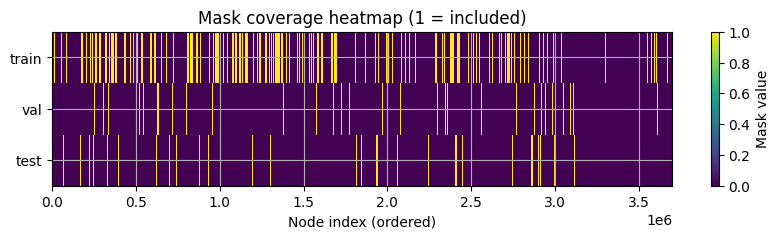

In [19]:
pos_nodes = torch.nonzero(graph.ndata["label"]).view(-1)
print(f'Positive nodes available: {pos_nodes.numel()}')
preview_nodes(graph, node_ids=pos_nodes[:5].cpu().numpy(), k=5)


## Next steps

- Edit `manual_preprocess()` to try alternative splits or timestamp sanity checks.
- Swap in different visualization slices (e.g., focus on positive nodes) to continue exploring the DGL graph.


# SCRATCH


In [2]:
import torch
print(f'torch version : {torch.__version__}')


torch version : 2.9.1
